In [14]:
!pip install PyPDF2

In [16]:
from google.colab import files

uploaded = files.upload()

Saving Resume1.pdf to Resume1 (1).pdf


In [17]:
import PyPDF2

def extract_text(pdf_file):

    text = ""

    pdf_reader = PyPDF2.PdfReader(pdf_file)

    for page in pdf_reader.pages:
        text += page.extract_text()

    return text

In [18]:
resume_files = [
    "Resume1.pdf",
    "Resume2.pdf",
    "Resume3.pdf"
]

resume_texts = []

for file in resume_files:

    text = extract_text(file)

    resume_texts.append(text)

print("All Resumes Loaded Successfully")

All Resumes Loaded Successfully


In [19]:
job_description = """
Python Developer

Required Skills:

Python
SQL
Machine Learning
Pandas
Flask
Data Analysis
"""

print(job_description)


Python Developer

Required Skills:

Python
SQL
Machine Learning
Pandas
Flask
Data Analysis



In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

documents = resume_texts.copy()

documents.append(job_description)

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

similarity_scores = cosine_similarity(
    tfidf_matrix[-1],
    tfidf_matrix[:-1]
)

scores = similarity_scores.flatten() * 100

scores

array([50.60619651,  4.03781247, 31.62487631])

In [21]:
import pandas as pd

ranking_df = pd.DataFrame({

    "Candidate":[
        "Rahul Kumar",
        "Priya Sharma",
        "Arjun Reddy"
    ],

    "Match Score":scores

})

ranking_df = ranking_df.sort_values(
    by="Match Score",
    ascending=False
)

ranking_df

,Candidate,Match Score
0,Rahul Kumar,50.606197
2,Arjun Reddy,31.624876
1,Priya Sharma,4.037812


In [22]:
print("Candidate Ranking")

print()

for index,row in ranking_df.iterrows():

    print(
        row["Candidate"],
        "->",
        round(row["Match Score"],2),
        "%"
    )

Candidate Ranking

Rahul Kumar -> 50.61 %
Arjun Reddy -> 31.62 %
Priya Sharma -> 4.04 %


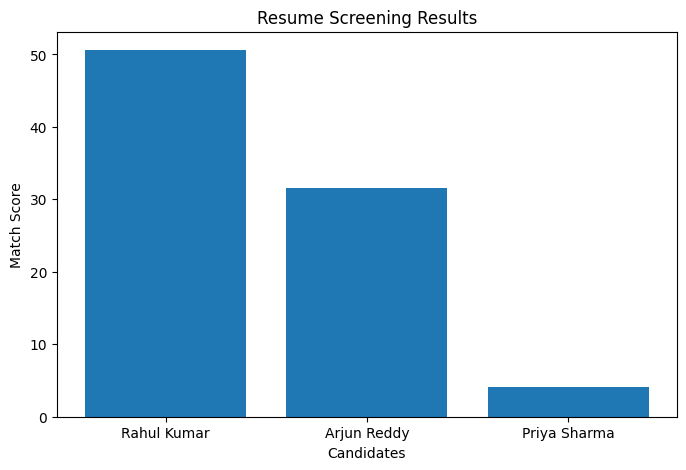

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    ranking_df["Candidate"],
    ranking_df["Match Score"]
)

plt.title(
    "Resume Screening Results"
)

plt.xlabel(
    "Candidates"
)

plt.ylabel(
    "Match Score"
)

plt.show()

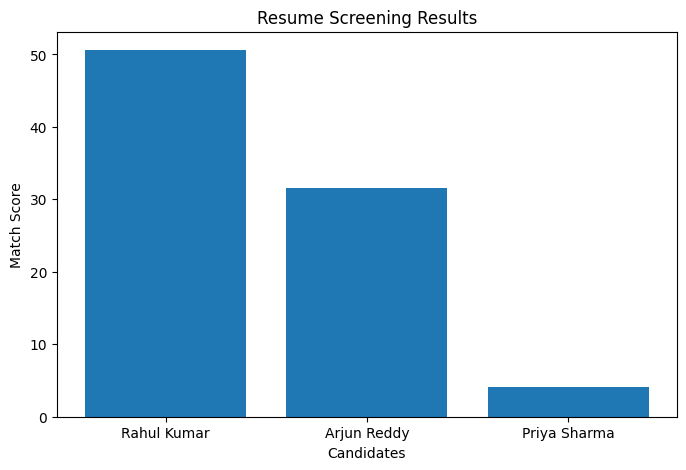

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    ranking_df["Candidate"],
    ranking_df["Match Score"]
)

plt.title(
    "Resume Screening Results"
)

plt.xlabel(
    "Candidates"
)

plt.ylabel(
    "Match Score"
)

plt.savefig(
    "candidate_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
files.download(
    "candidate_ranking.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>